In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Kaggle/Supervised Classification/transactions_fraud_dection.csv')

In [ ]:
df

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299690,299691,6000,996,45,27.93,34.07,ES,ES,web,grocery,0,1,1,0,2024-09-29T04:40:54Z,218.55,0
299691,299692,6000,996,45,27.93,68.56,ES,ES,app,travel,0,1,1,1,2024-10-03T08:49:02Z,185.55,0
299692,299693,6000,996,45,27.93,25.02,ES,ES,app,fashion,0,1,1,1,2024-10-26T07:40:38Z,33.50,0
299693,299694,6000,996,45,27.93,23.92,ES,ES,web,gaming,0,0,0,0,2024-10-27T09:31:56Z,71.75,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# drop unwanted columns
df.drop(columns=['transaction_id','user_id','promo_used','transaction_time'],inplace=True)
df

,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
0,141,47,147.93,84.75,FR,FR,web,travel,1,1,1,370.95,0
1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,149.62,0
2,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,164.08,0
3,141,47,147.93,112.47,FR,FR,web,fashion,1,1,1,397.40,0
4,141,47,147.93,132.91,FR,US,web,electronics,1,1,1,935.28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299690,996,45,27.93,34.07,ES,ES,web,grocery,1,1,0,218.55,0
299691,996,45,27.93,68.56,ES,ES,app,travel,1,1,1,185.55,0
299692,996,45,27.93,25.02,ES,ES,app,fashion,1,1,1,33.50,0
299693,996,45,27.93,23.92,ES,ES,web,gaming,0,0,0,71.75,0


In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,293083
1,6612


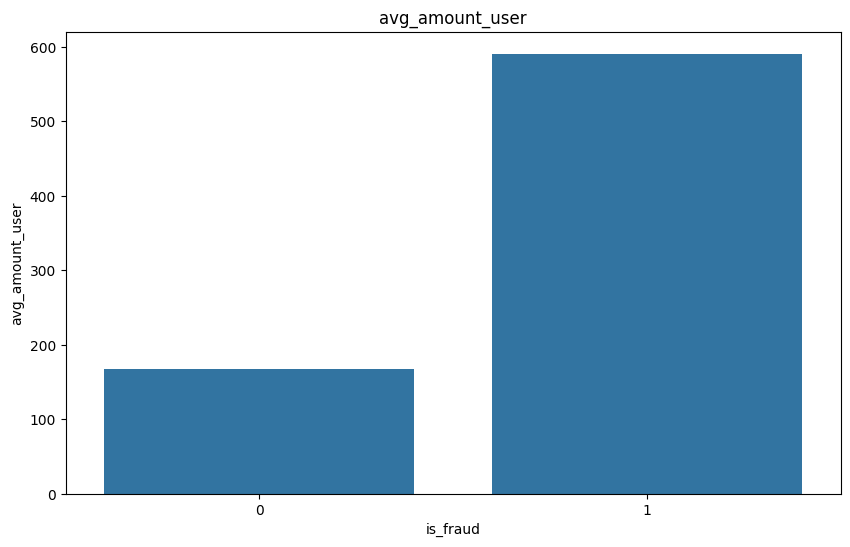

In [ ]:
avg_amount_user=df.groupby('is_fraud')['amount'].mean()
plt.figure(figsize=(10,6))
sns.barplot(x=avg_amount_user.index,y=avg_amount_user.values)
plt.xlabel('is_fraud')
plt.ylabel('avg_amount_user')
plt.title('avg_amount_user')
plt.show()

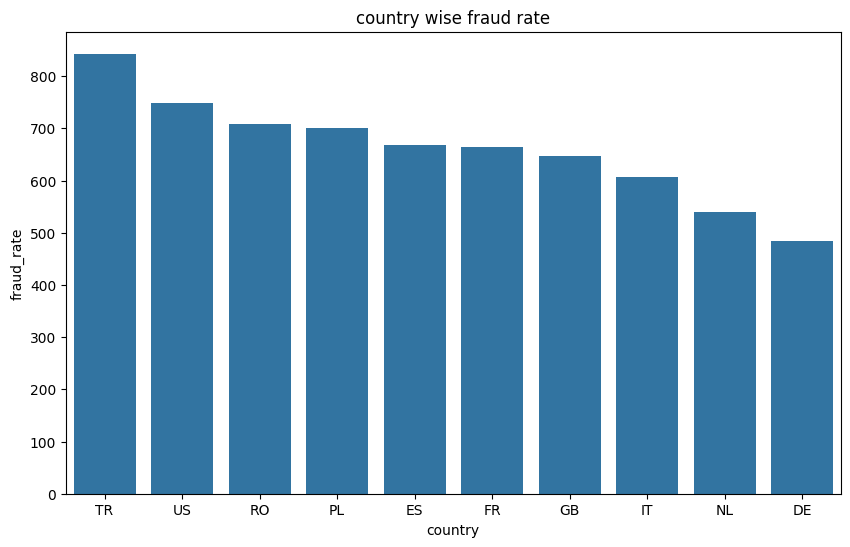

In [ ]:
country_fraud_rate=df.groupby('country')['is_fraud'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=country_fraud_rate.index,y=country_fraud_rate.values)
plt.xlabel('country')
plt.ylabel('fraud_rate')
plt.title('country wise fraud rate')
plt.show()

In [ ]:
df.groupby('merchant_category')['is_fraud'].sum().sort_values(ascending=False)

,is_fraud
merchant_category,
travel,1388
electronics,1357
fashion,1340
gaming,1295
grocery,1232


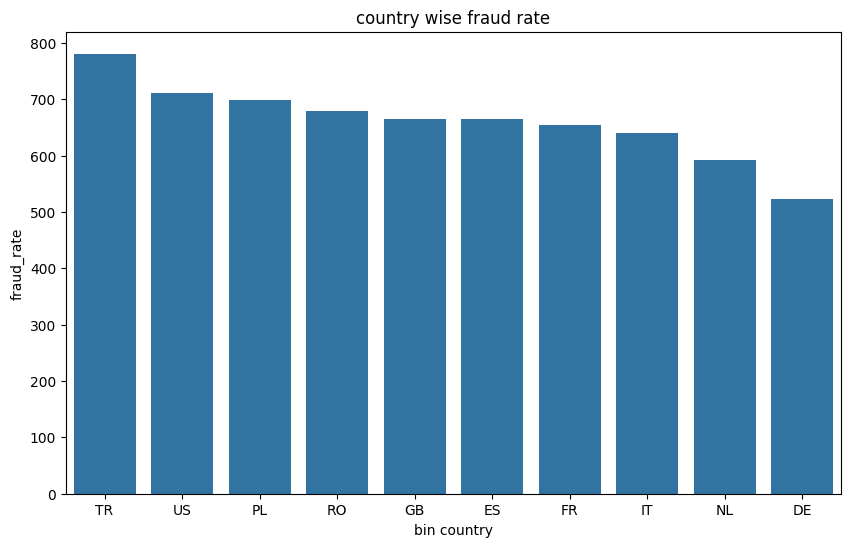

In [ ]:
bin_country_fraud_rate=df.groupby('bin_country')['is_fraud'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=bin_country_fraud_rate.index,y=bin_country_fraud_rate.values)
plt.xlabel('bin country')
plt.ylabel('fraud_rate')
plt.title('country wise fraud rate')
plt.show()

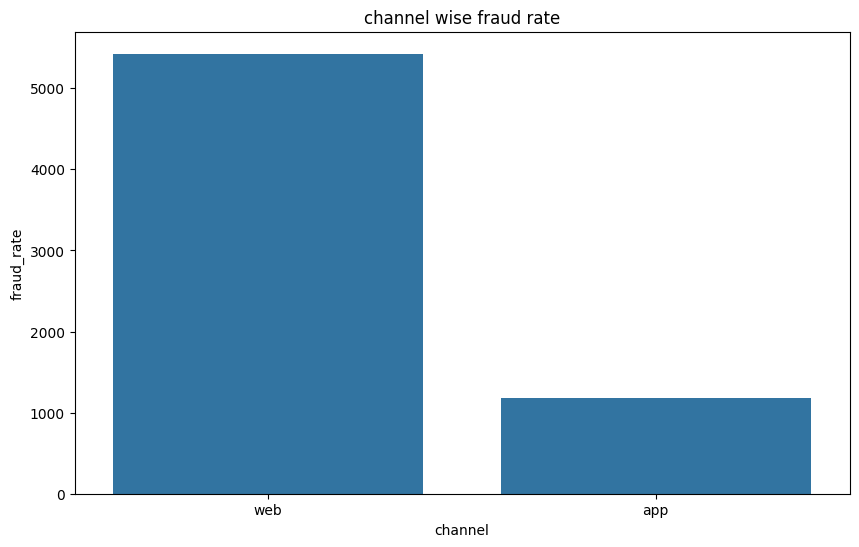

In [ ]:
channel_wise_fraudrate=df.groupby('channel')['is_fraud'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=channel_wise_fraudrate.index,y=channel_wise_fraudrate.values)
plt.xlabel('channel')
plt.ylabel('fraud_rate')
plt.title('channel wise fraud rate')
plt.show()

In [ ]:
# cvv_result
df.groupby('cvv_result')['is_fraud'].sum().sort_values(ascending=False)

,is_fraud
cvv_result,
0,4065
1,2547


In [ ]:
# three_ds_flag
df.groupby('three_ds_flag')['is_fraud'].sum().sort_values(ascending=False)

,is_fraud
three_ds_flag,
0,4359
1,2253


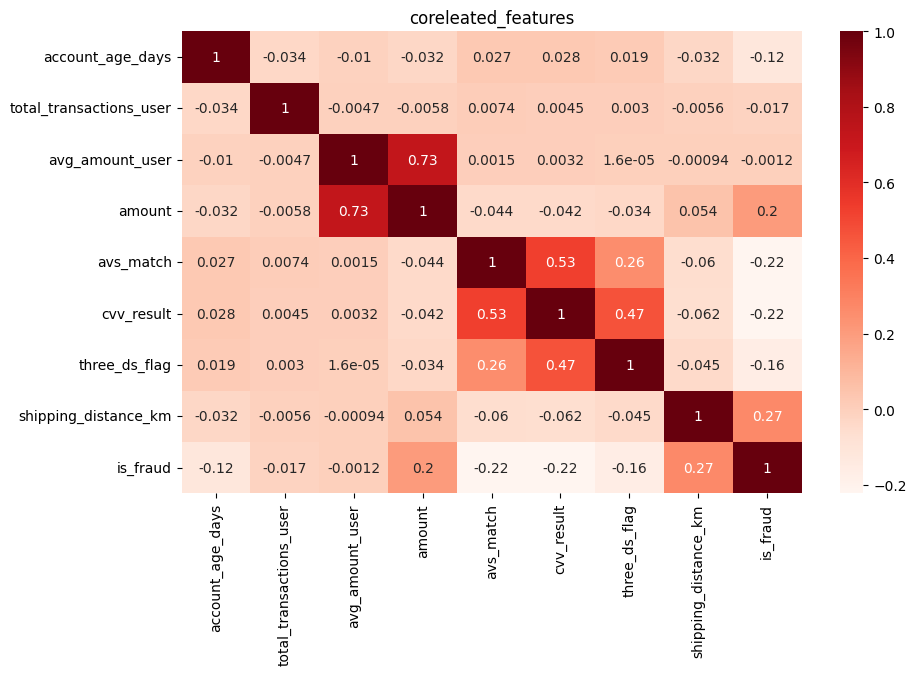

In [ ]:
# heat map for numerical features
coreleated_features=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,6))
sns.heatmap(coreleated_features,annot=True,cmap='Reds')
plt.title('coreleated_features')
plt.show()

In [ ]:
df.drop('avg_amount_user',axis=1,inplace=True)

In [ ]:
cat=df.select_dtypes(exclude=np.number).columns
cat

Index(['country', 'bin_country', 'channel', 'merchant_category'], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
mappings={}
for i in cat:
  df[i]=le.fit_transform(df[i])
  mappings[i]=dict(zip(le.classes_,le.transform(le.classes_)))

for i,j in mappings.items():
  print(f'{i} : {j}')

country : {'DE': np.int64(0), 'ES': np.int64(1), 'FR': np.int64(2), 'GB': np.int64(3), 'IT': np.int64(4), 'NL': np.int64(5), 'PL': np.int64(6), 'RO': np.int64(7), 'TR': np.int64(8), 'US': np.int64(9)}
bin_country : {'DE': np.int64(0), 'ES': np.int64(1), 'FR': np.int64(2), 'GB': np.int64(3), 'IT': np.int64(4), 'NL': np.int64(5), 'PL': np.int64(6), 'RO': np.int64(7), 'TR': np.int64(8), 'US': np.int64(9)}
channel : {'app': np.int64(0), 'web': np.int64(1)}
merchant_category : {'electronics': np.int64(0), 'fashion': np.int64(1), 'gaming': np.int64(2), 'grocery': np.int64(3), 'travel': np.int64(4)}


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   account_age_days         299695 non-null  int64  
 1   total_transactions_user  299695 non-null  int64  
 2   amount                   299695 non-null  float64
 3   country                  299695 non-null  int64  
 4   bin_country              299695 non-null  int64  
 5   channel                  299695 non-null  int64  
 6   merchant_category        299695 non-null  int64  
 7   avs_match                299695 non-null  int64  
 8   cvv_result               299695 non-null  int64  
 9   three_ds_flag            299695 non-null  int64  
 10  shipping_distance_km     299695 non-null  float64
 11  is_fraud                 299695 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 27.4 MB


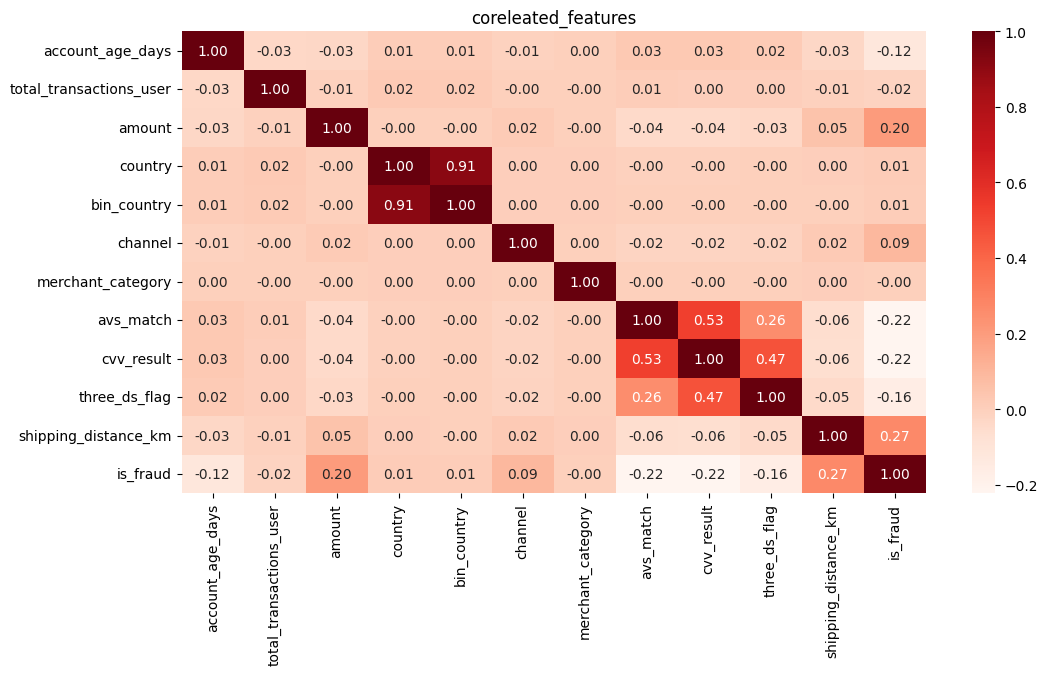

In [ ]:
# heat map for numerical features
coreleated_features=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12,6))
sns.heatmap(coreleated_features,annot=True,cmap='Reds',fmt='.2f')
plt.title('coreleated_features')
plt.show()

In [ ]:
df1=df.copy()

In [ ]:
x=df.drop('is_fraud',axis=1)
y=df['is_fraud']

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [ ]:
x_scaled=ss.fit_transform(x)
x_scaled

array([[-1.58479367, -0.61463968, -0.30109955, ...,  0.38294174,
         0.5239798 ,  0.03250387],
       [-1.58479367, -0.61463968, -0.2256742 , ..., -2.61136331,
        -1.90847051, -0.48501968],
       [-1.58479367, -0.61463968, -0.2763053 , ...,  0.38294174,
         0.5239798 , -0.45120867],
       ...,
       [ 0.04303196, -0.94929035, -0.49570672, ...,  0.38294174,
         0.5239798 , -0.75653658],
       [ 0.04303196, -0.94929035, -0.49929065, ..., -2.61136331,
        -1.90847051, -0.66709875],
       [ 0.04303196, -0.94929035, -0.4922857 , ...,  0.38294174,
         0.5239798 , -0.00285038]])

In [ ]:
# using rfe to train model
import statsmodels.api as sm
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [ ]:
# model=SVC()
model=LogisticRegression()
rfe=RFE(estimator=model,n_features_to_select=6)
rfe.fit(x,y)

RFE(estimator=LogisticRegression(), n_features_to_select=6)

In [ ]:
selected_features = x.columns[rfe.support_]
selected_features

Index(['total_transactions_user', 'country', 'channel', 'avs_match',
       'cvv_result', 'three_ds_flag'],
      dtype='object')

In [ ]:
x_rfe=x[selected_features]
x_rfe

,total_transactions_user,country,channel,avs_match,cvv_result,three_ds_flag
0,47,2,1,1,1,1
1,47,2,1,0,0,0
2,47,2,0,1,1,1
3,47,2,1,1,1,1
4,47,2,1,1,1,1
...,...,...,...,...,...,...
299690,45,1,1,1,1,0
299691,45,1,0,1,1,1
299692,45,1,0,1,1,1
299693,45,1,1,0,0,0


In [ ]:
x_rfe_scaled=ss.fit_transform(x_rfe)
x_rfe_scaled

array([[-0.61463968, -0.8868205 ,  0.98425119,  0.43968099,  0.38294174,
         0.5239798 ],
       [-0.61463968, -0.8868205 ,  0.98425119, -2.27437626, -2.61136331,
        -1.90847051],
       [-0.61463968, -0.8868205 , -1.0160008 ,  0.43968099,  0.38294174,
         0.5239798 ],
       ...,
       [-0.94929035, -1.23364757, -1.0160008 ,  0.43968099,  0.38294174,
         0.5239798 ],
       [-0.94929035, -1.23364757,  0.98425119, -2.27437626, -2.61136331,
        -1.90847051],
       [-0.94929035, -1.23364757,  0.98425119,  0.43968099,  0.38294174,
         0.5239798 ]])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_rfe_scaled,y,test_size=0.2,random_state=42,stratify=y)
# x_train,x_test,y_train,y_test=train_test_split(x_rfe_scaled,y,test_size=0.2,random_state=42)


In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((239756, 6), (59939, 6), (239756,), (59939,))

In [ ]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred)*100)
print(confusion_matrix(y_test,y_pred))

97.79442433140359
[[58617     0]
 [ 1322     0]]


In [ ]:
x_scaled

array([[-1.58479367, -0.61463968, -0.30109955, ...,  0.38294174,
         0.5239798 ,  0.03250387],
       [-1.58479367, -0.61463968, -0.2256742 , ..., -2.61136331,
        -1.90847051, -0.48501968],
       [-1.58479367, -0.61463968, -0.2763053 , ...,  0.38294174,
         0.5239798 , -0.45120867],
       ...,
       [ 0.04303196, -0.94929035, -0.49570672, ...,  0.38294174,
         0.5239798 , -0.75653658],
       [ 0.04303196, -0.94929035, -0.49929065, ..., -2.61136331,
        -1.90847051, -0.66709875],
       [ 0.04303196, -0.94929035, -0.4922857 , ...,  0.38294174,
         0.5239798 , -0.00285038]])

In [ ]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
lr1=LogisticRegression()
lr1.fit(x_train1,y_train1)
y_pred1=lr1.predict(x_test1)
print(accuracy_score(y_test1,y_pred1)*100)

98.29826990773954


In [ ]:
print(confusion_matrix(y_test1,y_pred1))

[[58492   125]
 [  895   427]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train1,y_train1)
y_pred2=rf.predict(x_test1)
print(accuracy_score(y_test1,y_pred2))
print(confusion_matrix(y_test1,y_pred2))

0.9914079313969202
[[58514   103]
 [  412   910]]


In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score, cohen_kappa_score

In [ ]:
cks = cohen_kappa_score(y_test1, y_pred2)
print(f"Cohen's Kappa Score: {cks:.2f}")

Cohen's Kappa Score: 0.78


**SMOTE** (Synthetic Minority Over-sampling Technique) is used to address class imbalance in datasets. In your dataset, the 'is_fraud' column shows a significant imbalance (293083 non-fraudulent vs. 6612 fraudulent transactions). This imbalance can lead to models that perform poorly on the minority class (fraudulent transactions). SMOTE helps by generating synthetic samples for the minority class, thereby balancing the dataset and potentially improving the model's ability to detect fraud.

In [ ]:
!pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f'Original dataset shape %s' % Counter(y_train1))

sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(x_train1, y_train1)

print(f'Resampled dataset shape %s' % Counter(y_res))

Original dataset shape Counter({0: 234466, 1: 5290})
Resampled dataset shape Counter({0: 234466, 1: 234466})


In [ ]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(x_res, y_res)

y_pred_smote = rf_smote.predict(x_test1)

print('RandomForestClassifier with SMOTE:')
print(f'Accuracy: {accuracy_score(y_test1, y_pred_smote)*100:.2f}%')
print('Confusion Matrix:')
print(confusion_matrix(y_test1, y_pred_smote))
print('Classification Report:')
print(classification_report(y_test1, y_pred_smote))

cks_smote = cohen_kappa_score(y_test1, y_pred_smote)
print(f"Cohen's Kappa Score: {cks_smote:.2f}")

RandomForestClassifier with SMOTE:
Accuracy: 98.54%
Confusion Matrix:
[[58052   565]
 [  311  1011]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     58617
           1       0.64      0.76      0.70      1322

    accuracy                           0.99     59939
   macro avg       0.82      0.88      0.85     59939
weighted avg       0.99      0.99      0.99     59939

Cohen's Kappa Score: 0.69


### Precision-Recall Curve for RandomForestClassifier with SMOTE

The Precision-Recall (PR) curve is particularly informative for imbalanced classification problems, where the number of positive examples (fraudulent transactions) is much smaller than the number of negative examples (non-fraudulent transactions).

*   **Precision** measures the proportion of positive identifications that were actually correct (`TP / (TP + FP)`).
*   **Recall** (or sensitivity) measures the proportion of actual positives that were identified correctly (`TP / (TP + FN)`).

A high area under the curve (AUC-PR) represents both high recall and high precision, which is ideal. It shows the trade-off between precision and recall for different threshold settings.

Area Under the Precision-Recall Curve (AUCPR) for SMOTE model: 0.77


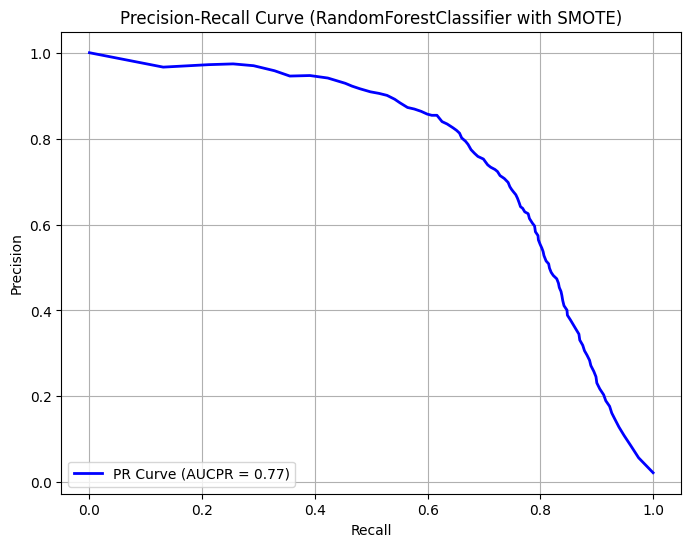

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions for the positive class (is_fraud = 1)
y_scores_smote = rf_smote.predict_proba(x_test1)[:, 1]

# Calculate precision, recall, and thresholds
precision_smote, recall_smote, thresholds_smote = precision_recall_curve(y_test1, y_scores_smote)

# Calculate Area Under the Precision-Recall Curve (AUCPR)
auc_pr_smote = auc(recall_smote, precision_smote)

print(f"Area Under the Precision-Recall Curve (AUCPR) for SMOTE model: {auc_pr_smote:.2f}")

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_smote, precision_smote, color='blue', lw=2, label=f'PR Curve (AUCPR = {auc_pr_smote:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (RandomForestClassifier with SMOTE)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### ROC Curve for RandomForestClassifier with SMOTE

The Receiver Operating Characteristic (ROC) curve is another common tool for evaluating the performance of binary classifiers. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

*   **True Positive Rate (TPR)**: Also known as recall or sensitivity, it measures the proportion of actual positive cases that are correctly identified.
*   **False Positive Rate (FPR)**: Measures the proportion of actual negative cases that are incorrectly identified as positive.

The Area Under the ROC Curve (AUC-ROC) summarizes the overall performance of a classifier across all possible classification thresholds. An AUC closer to 1 indicates a better model performance.

Area Under the ROC Curve (AUC-ROC) for SMOTE model: 0.97


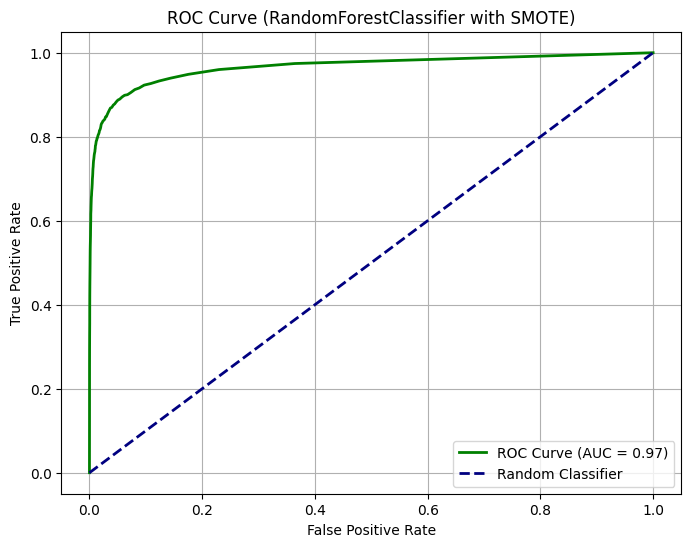

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions for the positive class (is_fraud = 1)
y_scores_smote = rf_smote.predict_proba(x_test1)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr_smote, tpr_smote, thresholds_roc_smote = roc_curve(y_test1, y_scores_smote)

# Calculate Area Under the ROC Curve (AUC-ROC)
auc_roc_smote = roc_auc_score(y_test1, y_scores_smote)

print(f"Area Under the ROC Curve (AUC-ROC) for SMOTE model: {auc_roc_smote:.2f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_smote, tpr_smote, color='green', lw=2, label=f'ROC Curve (AUC = {auc_roc_smote:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (RandomForestClassifier with SMOTE)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Area Under the Precision-Recall Curve (AUCPR): 0.82


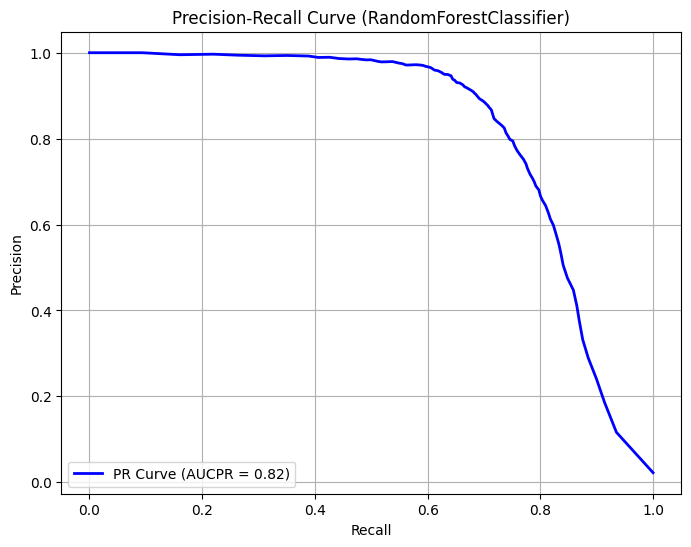

In [ ]:
# Get probability predictions for the positive class (is_fraud = 1)
y_probability = rf.predict_proba(x_test1)[:, 1]

# Calculate precision, recall, and thresholds
precision_smote, recall_smote, thresholds_smote = precision_recall_curve(y_test1, y_probability)

# Calculate Area Under the Precision-Recall Curve (AUCPR)
auc_pr_smote = auc(recall_smote, precision_smote)

print(f"Area Under the Precision-Recall Curve (AUCPR): {auc_pr_smote:.2f}")

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_smote, precision_smote, color='blue', lw=2, label=f'PR Curve (AUCPR = {auc_pr_smote:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (RandomForestClassifier)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()